In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import scipy.stats
from scipy.stats import linregress
import os
import xarray as xr
from matplotlib.lines import Line2D


In [2]:
models = [
    "CESM2", "CESM2-WACCM",
    "GFDL-CM4", "GFDL-ESM4",
    "IPSL-CM6A-LR", 
    "GISS-E2-1-G", #"GISS-E2-1-G-CC",
    "MIROC-ES2L",
    "NorCPM1", "NorESM2-LM", "NorESM2-MM",
      "MPI-ESM-1-2-HAM", "MPI-ESM1-2-HR", #"MPI-ESM1-2-LR"
    "UKESM1-0-LL",
    "CNRM-ESM2-1",
    "ACCESS-ESM1-5",
    "CanESM5", "CanESM5-CanOE",
    "CMCC-ESM2",
   # "WOA23",
   # "Observations",
   # "Ensemble Mean",
]

# RGB colors, one per model above
_colors_rgb = [
    [255, 255,  38],   # CESM2            - bright yellow
    #[255, 182,   0],   # CESM2-FV2        - amber
    [255, 159,   0],   # CESM2-WACCM      - orange-amber
   # [204, 127,   0],   # CESM2-WACCM-FV2  - dark orange
    [255,   2,   2],   # GFDL-CM4         - red
    [255, 148, 255],   # GFDL-ESM4        - light magenta
    [255,   6, 255],   # IPSL-CM6A-LR     - magenta
   # [204,   0, 204],   # IPSL-CM6A-LR-INCA- dark magenta
   # [153,   0, 153],   # IPSL-CM5A2-INCA  - deep purple-magenta
    [127, 245, 206],   # GISS-E2-1-G      - seafoam
   # [170, 211, 255],   # GISS-E2-1-G-CC   - light blue
    [ 26, 136, 255],   # MIROC-ES2L       - medium blue
    [175, 255, 175],   # NorCPM1          - light green
    [ 17, 137,  14],   # NorESM2-LM       - dark green
    [ 10,  92,   8],   # NorESM2-MM       - forest green
    [  8,   8, 126],   # MPI-ESM1-2-HR    - navy
    #[130,  55,   6],   # MPI-ESM1-2-LR    - brown
    [ 92,  58,  10],   # MPI-ESM-1-2-HAM  - dark brown
    [112,  48, 160],   # UKESM1-0-LL      - purple
    [184, 184, 255],   # CNRM-ESM2-1      - lavender
    [ 92,  92, 255],   # ACCESS-ESM1-5    - periwinkle
    [  4,   2,   0],   # CanESM5          - near-black
    [ 42,  42,  42],   # CanESM5-CanOE    - dark gray
    [232,  80,   0],   # CMCC-ESM2        - burnt orange
   # [  0, 200, 200],   # WOA23            - teal
   # [ 17,  17,  17],   # Observations     - black
   # [136, 136, 136],   # Ensemble Mean    - gray
]

colors = np.array([[r/255.0, g/255.0, b/255.0] for r, g, b in _colors_rgb])

Time_months = ("Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec")


In [3]:
def retrieve_data(model, var, start_year, end_year, region):
    pvar1 = ("/glade/work/diegovar/climatologiesthesis/" + model + "_" + var + "_"
             + region + "_" + start_year + end_year + ".txt")

    if not os.path.exists(pvar1):
        return None

    with open(pvar1, "r") as rf:
        raw = rf.read()

    # Strip numpy array brackets and split on any whitespace / commas
    raw = raw.replace("[", "").replace("]", "").replace(",", " ")
    dvar = [float(v) for v in raw.split() if v]

    return dvar if dvar else None

# Helper function to jitter points slightly to avoid overlap
def jitter(val, spread=0.04):
    return val + np.random.uniform(-spread, spread)

def plot_regression(ax, x, y):
    """Plot regression line + stats only when enough valid data points exist."""
    x = np.array(x)
    y = np.array(y)
    if len(x) < 3:
        return
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    if np.isnan(slope):
        return
    x_fit = np.linspace(np.min(x), np.max(x), 100)
    y_fit = slope * x_fit + intercept
    ax.plot(x_fit, y_fit, 'r--', label=f'Fit: y={slope:.2f}x+{intercept:.2f}')
    stats_text = f"R = {r_value:.2f}\nP = {p_value:.4f}\nSlope = {slope:.3f}"
    ax.text(0.70, 0.95, stats_text, transform=ax.transAxes,
            verticalalignment='top', fontsize=10,
            bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))


In [4]:
# Font size constants
TITLE_SIZE = 14
LABEL_SIZE = 12
TICK_SIZE  = 10
LEGEND_SIZE = 10

# Inputs
start_year = '1991'
end_year   = '2014'

regions = ['siz']


## Comparison - Reg Plots

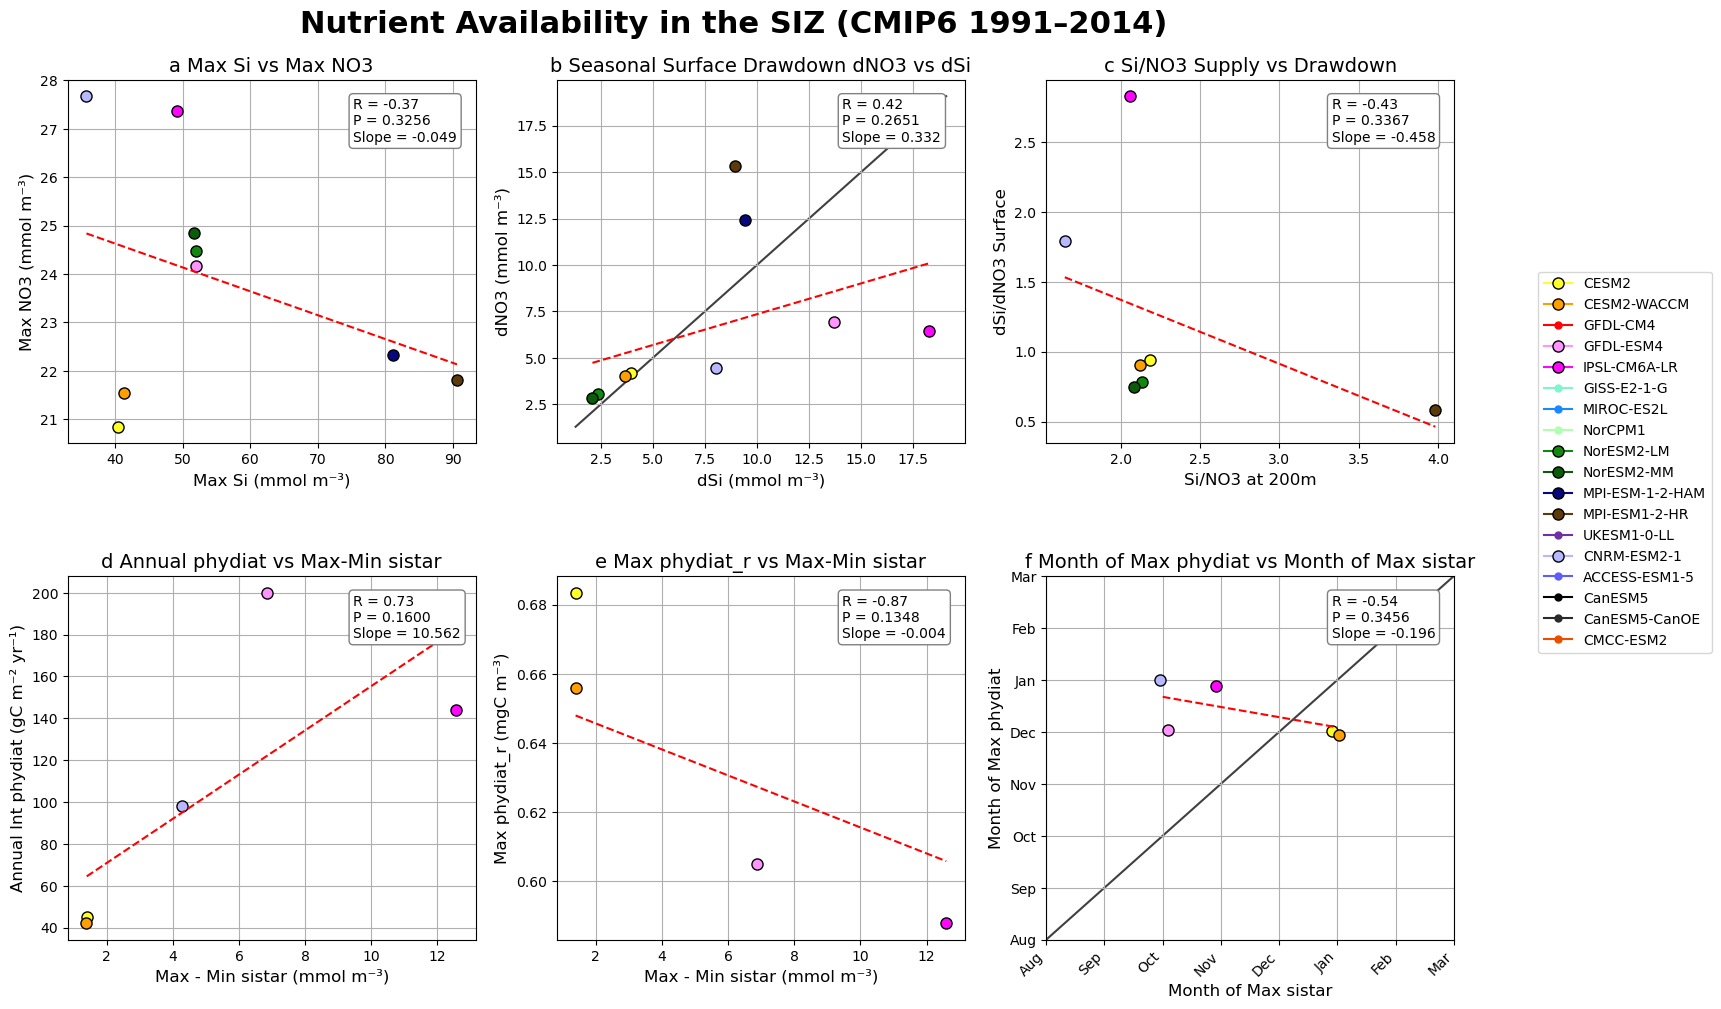

In [5]:
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(18, 10))

# ── 7a  Max Si vs Max NO3 ─────────────────────────────────────────────────
vals1, vals2 = [], []
for mi, model in enumerate(models):
    for region in regions:
        data1 = retrieve_data(model, 'si',  start_year, end_year, region)
        data2 = retrieve_data(model, 'no3', start_year, end_year, region)
        if data1 is not None and data2 is not None:
            maxvar1 = np.max(data1)
            maxvar2 = np.max(data2)
            vals1.append(maxvar1)
            vals2.append(maxvar2)
            ax1.plot((maxvar1), (maxvar2), label=model,
                     marker='o', markersize=8, color=colors[mi], markeredgecolor='black')
        else:
            ax1.plot([], [], label=model, marker='o', markersize=5, color=colors[mi])
            
plot_regression(ax1, vals1, vals2)
ax1.set_xlabel('Max Si (mmol m⁻³)')
ax1.set_ylabel('Max NO3 (mmol m⁻³)')
ax1.set_title('a Max Si vs Max NO3', fontsize=TITLE_SIZE)

# ── 7b  Seasonal Surface Drawdown dNO3 vs dSi ────────────────────────────
vals1, vals2 = [], []
for mi, model in enumerate(models):
    for region in regions:
        data1 = retrieve_data(model, 'no3', start_year, end_year, region)
        data2 = retrieve_data(model, 'si',  start_year, end_year, region)
        if data1 is not None and data2 is not None:
            diffvar1 = np.max(data1) - np.min(data1)
            diffvar2 = np.max(data2) - np.min(data2)
            vals1.append(diffvar1)
            vals2.append(diffvar2)
            ax2.plot((diffvar2), (diffvar1), label=model,
                     marker='o', markersize=8, color=colors[mi], markeredgecolor='black')
        else:
            ax2.plot([], [], label=model, marker='o', markersize=5, color=colors[mi])
plot_regression(ax2, vals2, vals1)
ax2.set_xlabel('dSi (mmol m⁻³)')
ax2.set_ylabel('dNO3 (mmol m⁻³)')
ax2.set_title('b Seasonal Surface Drawdown dNO3 vs dSi', fontsize=TITLE_SIZE)
if vals1:
    lims = [min(ax2.get_xlim()[0], ax2.get_ylim()[0]),
            max(ax2.get_xlim()[1], ax2.get_ylim()[1])]
    ax2.plot(lims, lims, 'k-', alpha=0.75, zorder=0)

# ── 7c  Si/NO3 Supply vs Drawdown ────────────────────────────────────────
# BUG WAS HERE: condition used `data1`/`data2` (leftover from 7b scope)
# instead of `data1s`/`data2s`, so the if-branch never fired → nothing plotted
vals1, vals2 = [], []
for mi, model in enumerate(models):
    for region in regions:
        data1s    = retrieve_data(model, 'no3',     start_year, end_year, region)
        data2s    = retrieve_data(model, 'si',      start_year, end_year, region)
        data1200m = retrieve_data(model, 'no3_200m', start_year, end_year, region)
        data2200m = retrieve_data(model, 'si_200m',  start_year, end_year, region)
        if data1s is not None and data2s is not None and data1200m is not None and data2200m is not None:
            dSiS   = np.max(data2s)   - np.min(data2s)
            dNO3S  = np.max(data1s)   - np.min(data1s)
            ratios    = dSiS / dNO3S if dNO3S != 0 else np.nan
            ratio200m = np.mean(data2200m) / np.mean(data1200m) if np.mean(data1200m) != 0 else np.nan
            if np.isnan(ratios) or np.isnan(ratio200m):
                ax3.plot([], [], label=model, marker='o', markersize=5, color=colors[mi])
                continue
            vals1.append(ratios)
            vals2.append(ratio200m)
            ax3.plot((ratio200m), (ratios), label=model,
                     marker='o', markersize=8, color=colors[mi], markeredgecolor='black')
        else:
            ax3.plot([], [], label=model, marker='o', markersize=5, color=colors[mi])
plot_regression(ax3, vals2, vals1)
ax3.set_xlabel('Si/NO3 at 200m')
ax3.set_ylabel('dSi/dNO3 Surface')
ax3.set_title('c Si/NO3 Supply vs Drawdown', fontsize=TITLE_SIZE)

# ── 7d  Annual phydiat vs Max-Min sistar ─────────────────────────────────
vals1, vals2 = [], []
for mi, model in enumerate(models):
    for region in regions:
        data1 = retrieve_data(model, 'phydiat', start_year, end_year, region)
        data2 = retrieve_data(model, 'sistar',  start_year, end_year, region)
        if data1 is not None and data2 is not None:
            annualvar1 = np.sum(data1)
            diffvar2   = np.max(data2) - np.min(data2)
            vals1.append(annualvar1)
            vals2.append(diffvar2)
            ax4.plot(jitter(diffvar2), jitter(annualvar1), label=model,
                     marker='o', markersize=8, color=colors[mi],
                    markeredgecolor='black')
        else:
            ax4.plot([], [], label=model, marker='o', markersize=5, color=colors[mi])
plot_regression(ax4, vals2, vals1)
ax4.set_xlabel('Max - Min sistar (mmol m⁻³)')
ax4.set_ylabel('Annual Int phydiat (gC m⁻² yr⁻¹)')
ax4.set_title('d Annual phydiat vs Max-Min sistar', fontsize=TITLE_SIZE)

# ── 7e  Max phydiat_r vs Max-Min sistar ──────────────────────────────────
vals1, vals2 = [], []
for mi, model in enumerate(models):
    for region in regions:
        data1 = retrieve_data(model, 'phydiat_r', start_year, end_year, region)
        data2 = retrieve_data(model, 'sistar',    start_year, end_year, region)
        if data1 is not None and data2 is not None:
            maxvar1  = np.max(data1)
            diffvar2 = np.max(data2) - np.min(data2)
            vals1.append(maxvar1)
            vals2.append(diffvar2)
            ax5.plot(jitter(diffvar2), jitter(maxvar1), label=model,
                     marker='o', markersize=8, color=colors[mi], markeredgecolor='black')
        else:
            ax5.plot([], [], label=model, marker='o', markersize=5, color=colors[mi])
plot_regression(ax5, vals2, vals1)
ax5.set_xlabel('Max - Min sistar (mmol m⁻³)')
ax5.set_ylabel('Max phydiat_r (mgC m⁻³)')
ax5.set_title('e Max phydiat_r vs Max-Min sistar', fontsize=TITLE_SIZE)


# ── 7f  Month of Max phydiat vs Month of Max sistar ──────────────────────
sh_order      = [6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5]
sh_labels     = [Time_months[m - 1] for m in sh_order]
month_to_pos  = {m: p for p, m in enumerate(sh_order, start=1)}

vals1, vals2 = [], []
for mi, model in enumerate(models):
    for region in regions:
        data1 = retrieve_data(model, 'phydiat', start_year, end_year, region)
        data2 = retrieve_data(model, 'sistar',  start_year, end_year, region)
        if data1 is not None and data2 is not None:
            imaxvar1 = int(np.argmax(data1)) + 1
            imaxvar2 = int(np.argmax(data2)) + 1

            if imaxvar1 not in month_to_pos or imaxvar2 not in month_to_pos:
                print(f"  SKIPPED {model} / {region}: argmax out of 1-12 range "
                      f"(phydiat peak={imaxvar1}, sistar peak={imaxvar2}, "
                      f"len(data1)={len(data1)}, len(data2)={len(data2)})")
                ax6.plot([], [], label=model, marker='o', markersize=5, color=colors[mi])
                continue

            p1 = month_to_pos[imaxvar1]
            p2 = month_to_pos[imaxvar2]
            vals1.append(p1)
            vals2.append(p2)
            ax6.plot(jitter(p2, spread=0.15), jitter(p1, spread=0.15),
                     label=model, marker='o', markersize=8, color=colors[mi], markeredgecolor='black')
        else:
            ax6.plot([], [], label=model, marker='o', markersize=5, color=colors[mi])

plot_regression(ax6, vals2, vals1)
ax6.set_xlabel('Month of Max sistar')
ax6.set_ylabel('Month of Max phydiat')
ax6.set_title('f Month of Max phydiat vs Month of Max sistar', fontsize=TITLE_SIZE)
ax6.set_xticks(range(1, 13))
ax6.set_yticks(range(1, 13))
ax6.set_xticklabels(sh_labels, rotation=45, ha='right')
ax6.set_yticklabels(sh_labels)
ax6.set_xlim(3, 10)
ax6.set_ylim(3, 10)

if vals1:
    ax6.plot([3, 10], [3, 10], 'k-', alpha=0.75, zorder=0)
    

# ── Shared formatting ─────────────────────────────────────────────────────
for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
    ax.grid(True)
    ax.tick_params(axis='both', which='major', labelsize=TICK_SIZE)
    ax.xaxis.label.set_size(LABEL_SIZE)
    ax.yaxis.label.set_size(LABEL_SIZE)

fig.subplots_adjust(left=0.08, bottom=0.05, right=0.85, top=0.91, hspace=0.365, wspace=0.2)
fig.legend(models, loc='lower right', bbox_to_anchor=(0.997, 0.33), fontsize=LEGEND_SIZE)
plt.suptitle('Nutrient Availability in the SIZ (CMIP6 1991–2014)', fontsize=22, weight='bold', x=0.45)
plt.savefig('NutrientAvailability.png', dpi=600, format='png')

## Nutrient Time Series

CPU times: user 1.64 s, sys: 189 ms, total: 1.83 s
Wall time: 1.88 s


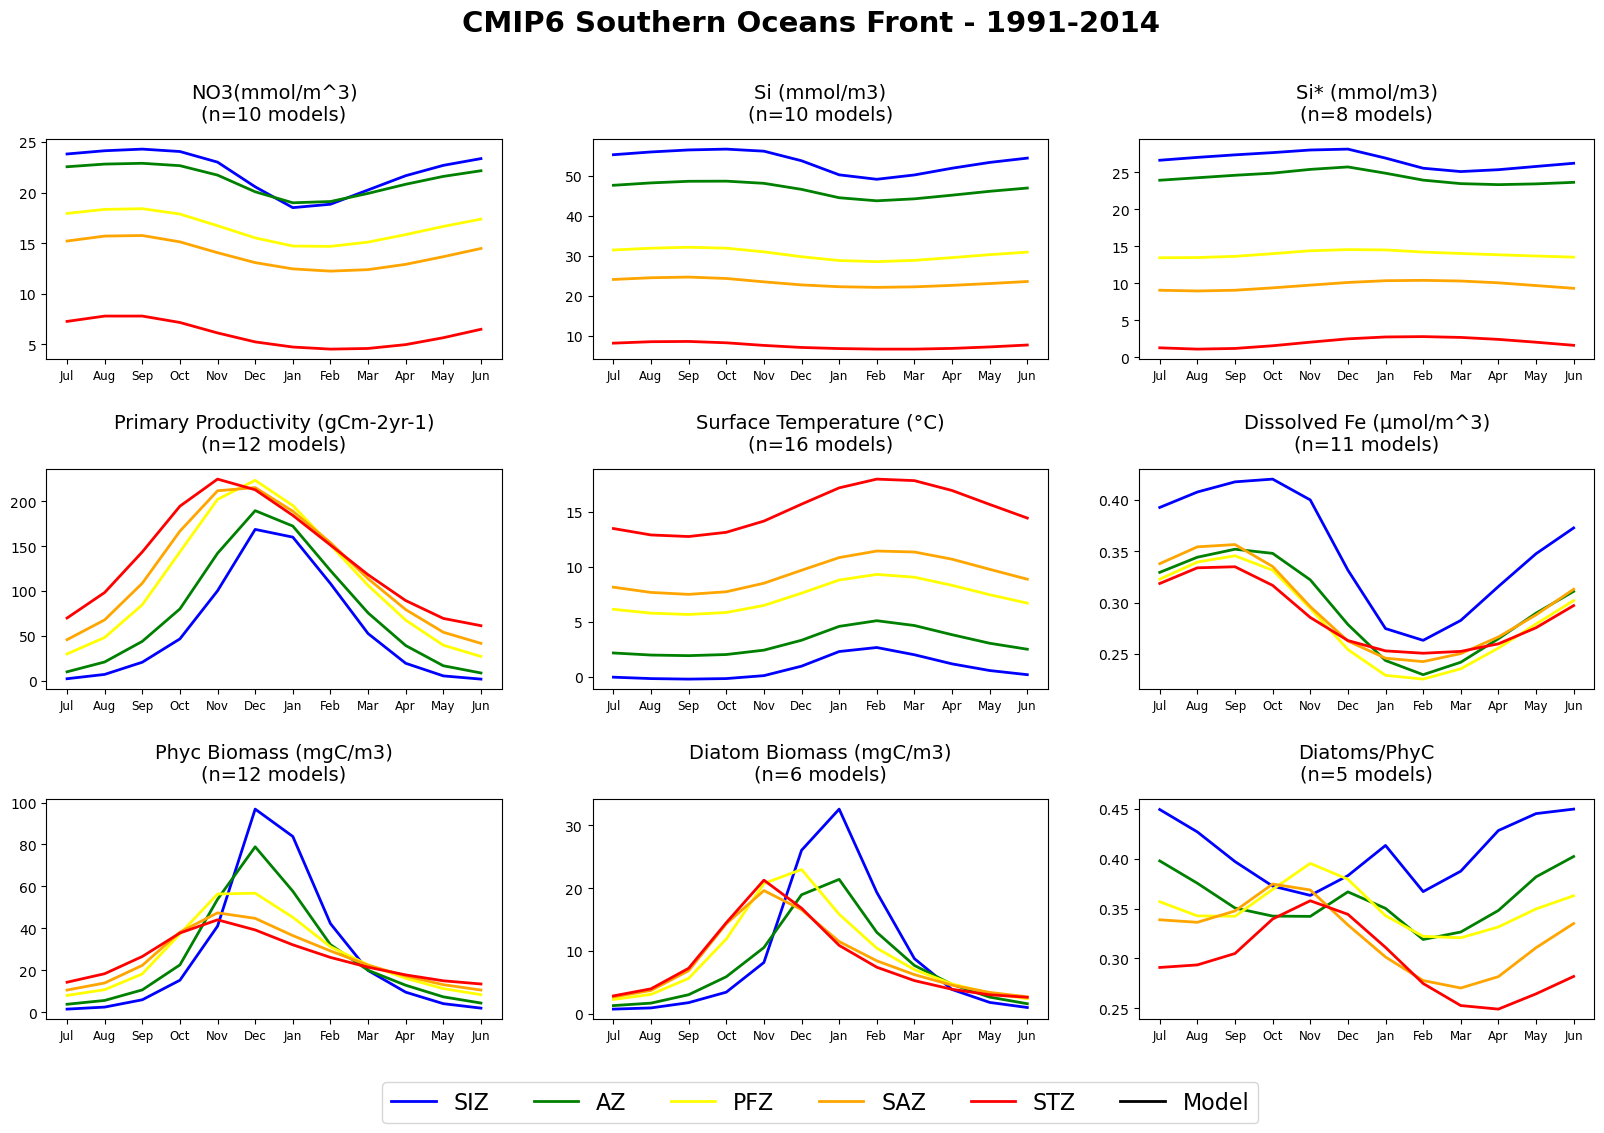

In [6]:
%%time
start_year = "1991"
end_year = "2014"

Time_months = ("Jul", "Aug", "Sep", "Oct", "Nov", "Dec", 
               "Jan", "Feb", "Mar", "Apr", "May", "Jun")


var_names = ["no3", 'si', "sistar", 'intpp', 'tos', 'dfe','phyc','phydiat',"phydiat_r"] # "phyc","chl","zooc","zooc_r","intpp","taum","tos","mlotst","no3","si*","dfe","phydiat_r",

plot_titles = [
    # "SST (°C)",
    "NO3(mmol/m^3)",
    "Si (mmol/m3)",
    "Si* (mmol/m3)",
    'Primary Productivity (gCm-2yr-1)',
    'Surface Temperature (°C)',
    "Dissolved Fe (μmol/m^3)",
    "Phyc Biomass (mgC/m3)",
    "Diatom Biomass (mgC/m3)",
    "Diatoms/PhyC",
]

# Regions and colors
regions = ['siz', 'az', 'pfz', 'saz', 'stz']

region_labels = {r: r.upper() for r in regions}

region_colors = {
    'siz': 'blue',
    'az': 'green',
    'pfz': 'yellow',
    'saz': 'orange',
    'stz': 'red'
}

# --- Plot ---
fig = plt.figure(figsize=(18, 10))
ncol, nrow =  3,3

for i, var in enumerate(var_names):
    ax = plt.subplot(ncol, nrow, i + 1)
    used_models = set()


    for region in regions:
        region_data = []

        # --- MODEL DATA ---
        for model in models:
            ofn = f"/glade/work/diegovar/climatologiesthesis/" + model + "_" + var + "_" + region + "_" + start_year + end_year + ".txt"
            if os.path.exists(ofn):
                with open(ofn, "r") as rf:
                    values = [float(line.strip()) for line in rf]
                    if len(values) == 12:
                        s = np.array(values)
                        s = np.roll(s, -6)  # roll 6 months
                        region_data.append(s)
                        used_models.add(model)
        if region_data:
            mean_vals = np.mean(np.array(region_data), axis=0)
            if var == 'fgco2':
                # multiply by 1e4 so 0.000150 -> 1.5
                mean_vals = mean_vals * 1e4
                ax.set_ylabel('×1e-4')
    
            ax.plot(np.arange(1, 13), mean_vals,
                    color=region_colors[region],
                    linestyle='-', linewidth=2, label=region_labels[region])
            

    ax.set_xticks(np.arange(1, 13))
    ax.set_xticklabels(Time_months, fontsize=8.5)
    ax.set_title(f"{plot_titles[i]}\n(n={len(used_models)} models)",
             fontsize=14, y=1.05,) #fontweight='bold')
# --- Legend ---
region_legend_elements = [
    Line2D([], [], color=region_colors[r], linestyle='-', linewidth=2, label=region_labels[r])
    for r in regions
]
style_legend = [
    Line2D([], [], color='black', linestyle='-', linewidth=2, label='Model'),
]

plt.subplots_adjust(left=0.03, bottom=0.03, right=0.89, top=0.91, hspace=0.50, wspace=0.2)

fig.legend(handles=region_legend_elements + style_legend, loc="lower center", fontsize = 16,
           bbox_to_anchor=(0.46, -0.085), ncol=len(region_legend_elements) + 2)

plt.suptitle(f"CMIP6 Southern Oceans Front - {start_year}-{end_year}",
             fontsize=21, weight="bold",   x=0.455, y = 1.04)

fig.patch.set_facecolor("white")
for ax in fig.axes:
    ax.set_facecolor("white")
    
plt.savefig("SouthernOceanModels.png", dpi=600, bbox_inches="tight", transparent = True)

## Map Agreement

In [23]:
"""
ensemble_polar_maps_per_model.py
─────────────────────────────────────────────────────────────────────────────
One row per model × 3 cols (Annual, November, February)
One figure per variable (sistar, si, no3)
─────────────────────────────────────────────────────────────────────────────
"""

import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ─── CONFIG ──────────────────────────────────────────────────────────────────
SAVE_DIR   = "/glade/work/diegovar/climatologies_spatial1"
START_YEAR = "1991"
END_YEAR   = "2014"

MODELS = [
    "CESM2", "CESM2-WACCM",
    "GFDL-CM4", "GFDL-ESM4",
    "IPSL-CM6A-LR", 
    "GISS-E2-1-G", #"GISS-E2-1-G-CC",
    "MIROC-ES2L",
    "NorCPM1", "NorESM2-LM", "NorESM2-MM",
    "MPI-ESM-1-2-HAM", "MPI-ESM1-2-HR", #"MPI-ESM1-2-LR"
    "UKESM1-0-LL",
    "CNRM-ESM2-1",
    "ACCESS-ESM1-5",
    "CanESM5", "CanESM5-CanOE",
    "CMCC-ESM2",
]

SKIP_COMBOS = {
    ("UKESM1-0-LL", "no3"),
}

VARIABLES  = ["sistar", "si", "no3"]
VAR_LABELS = {
    "sistar": r"Si* (mmol m$^{-3}$)",
    "si"    : r"Si  (mmol m$^{-3}$)",
    "no3"   : r"NO$_3$ (mmol m$^{-3}$)",
}
CMAPS = {"sistar": "RdBu_r", "si": "Blues",  "no3": "YlGn"}
VLIMS = {"sistar": (-20, 20), "si": (0, 60), "no3": (0, 35)}

TIME_PERIODS = {
    "Annual"  : None,
    "November": 11,
    "February": 2,
}

OUTPUT_DIR = "."
# ─────────────────────────────────────────────────────────────────────────────


def get_path(model, var):
    return os.path.join(SAVE_DIR, f"{model}_{var}_{START_YEAR}{END_YEAR}_spatial.nc")


def load_period(model, var, month):
    """Return (2-D field, lat, lon) or (None, None, None)."""
    if (model, var) in SKIP_COMBOS:
        return None, None, None
    path = get_path(model, var)
    if not os.path.exists(path):
        print(f"  [missing] {path}")
        return None, None, None
    ds    = xr.open_dataset(path)
    da    = ds[var]                        # (month, lat, lon)
    field = da.mean("month").values if month is None else da.sel(month=month).values
    return field, da["lat"].values, da["lon"].values


# ── map helpers ───────────────────────────────────────────────────────────────

def circular_boundary(ax):
    theta = np.linspace(0, 2 * np.pi, 300)
    verts = np.column_stack([np.sin(theta), np.cos(theta)])
    ax.set_boundary(mpath.Path(verts * 0.5 + 0.5), transform=ax.transAxes)


def setup_ax(ax):
    ax.set_extent([-180, 180, -90, -45], crs=ccrs.PlateCarree())
    circular_boundary(ax)
    ax.add_feature(cfeature.LAND,      facecolor="#aaaaaa", zorder=4)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4,        zorder=5)
    gl = ax.gridlines(crs=ccrs.PlateCarree(),
                      linewidth=0.3, color="grey", linestyle="--", zorder=3)
    gl.xlocator = plt.FixedLocator(range(-180, 181, 30))
    gl.ylocator = plt.FixedLocator([-80, -70, -60, -50])


# ── one figure per variable ───────────────────────────────────────────────────

def make_figure_for_var(var):
    period_names = list(TIME_PERIODS.keys())
    n_cols       = len(period_names)
    proj         = ccrs.SouthPolarStereo(central_longitude=0)

    # Collect data for all models first so we can skip missing ones cleanly
    rows = []   # list of (model_name, {pname: (field, lat, lon)})
    for model in MODELS:
        periods = {}
        for pname, month in TIME_PERIODS.items():
            field, lat, lon = load_period(model, var, month)
            periods[pname] = (field, lat, lon)
        # Only include model if at least one period loaded
        if any(v[0] is not None for v in periods.values()):
            rows.append((model, periods))

    if not rows:
        print(f"  [skip] no data at all for {var}")
        return

    n_rows = len(rows)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4.5 * n_cols, 4.2 * n_rows),
        subplot_kw={"projection": proj},
    )
    # Ensure axes is always 2-D
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    fig.subplots_adjust(hspace=0.06, wspace=0.04,
                        top=0.94, bottom=0.04, left=0.08, right=0.88)

    for row, (model, periods) in enumerate(rows):
        for col, pname in enumerate(period_names):
            ax             = axes[row, col]
            field, lat, lon = periods[pname]

            # Column header — top row only
            if row == 0:
                ax.set_title(pname, fontsize=11, fontweight="bold", pad=5)

            # Row label — left column only
            if col == 0:
                ax.text(-0.10, 0.5, model,
                        va="center", ha="right", rotation=90,
                        fontsize=8, fontweight="bold",
                        transform=ax.transAxes)

            if field is None:
                ax.axis("off")
                ax.text(0.5, 0.5, "no data", ha="center", va="center",
                        fontsize=8, transform=ax.transAxes, color="grey")
                continue

            lon2d, lat2d = np.meshgrid(lon, lat)
            setup_ax(ax)

            cf = ax.pcolormesh(
                lon2d, lat2d, field,
                vmin=VLIMS[var][0], vmax=VLIMS[var][1],
                cmap=CMAPS[var],
                transform=ccrs.PlateCarree(),
                shading="auto", zorder=1,
            )

            # Colourbar on rightmost column only
            if col == n_cols - 1:
                cbar = fig.colorbar(cf, ax=ax,
                                    orientation="vertical",
                                    fraction=0.046, pad=0.04, shrink=0.80)
                cbar.set_label(VAR_LABELS[var], fontsize=7)
                cbar.ax.tick_params(labelsize=6)

    fig.suptitle(
        f"CMIP6 Individual Models  —  {VAR_LABELS[var]}\n"
        f"Historical {START_YEAR}–{END_YEAR}  |  Southern Ocean",
        fontsize=12, fontweight="bold",
    )

    out = os.path.join(OUTPUT_DIR, f"Nutrients_spatial_per_model_{var}.png")
    plt.savefig(out, dpi=300, bbox_inches="tight")
    print(f"Saved → {out}")
    plt.close(fig)


# ── entry point ───────────────────────────────────────────────────────────────

if __name__ == "__main__":
    for var in VARIABLES:
        print(f"\n{'='*50}\n  {var}\n{'='*50}")
        make_figure_for_var(var)


  sistar
  [missing] /glade/work/diegovar/climatologies_spatial1/GFDL-CM4_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/GFDL-CM4_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/GFDL-CM4_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/GISS-E2-1-G_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/GISS-E2-1-G_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/GISS-E2-1-G_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/MIROC-ES2L_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/MIROC-ES2L_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/MIROC-ES2L_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/NorCPM1_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/


── sistar  |  Annual ──
  [missing] /glade/work/diegovar/climatologies_spatial1/GFDL-CM4_sistar_19912014_spatial.nc
  [align lat] IPSL-CM6A-LR
  [missing] /glade/work/diegovar/climatologies_spatial1/GISS-E2-1-G_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/MIROC-ES2L_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/NorCPM1_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/MPI-ESM-1-2-HAM_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/UKESM1-0-LL_sistar_19912014_spatial.nc
  [align lat] CNRM-ESM2-1
  [missing] /glade/work/diegovar/climatologies_spatial1/ACCESS-ESM1-5_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/CanESM5_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/CanESM5-CanOE_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/CMCC-ESM2_sista

/glade/derecho/scratch/diegovar/tmp/ipykernel_76843/1286263186.py:137: RuntimeWarning: Mean of empty slice
  ens_mean = np.nanmean(stack, axis=0)
/glade/derecho/scratch/diegovar/tmp/ipykernel_76843/1286263186.py:137: RuntimeWarning: Mean of empty slice
  ens_mean = np.nanmean(stack, axis=0)



── sistar  |  February ──
  [missing] /glade/work/diegovar/climatologies_spatial1/GFDL-CM4_sistar_19912014_spatial.nc
  [align lat] IPSL-CM6A-LR
  [missing] /glade/work/diegovar/climatologies_spatial1/GISS-E2-1-G_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/MIROC-ES2L_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/NorCPM1_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/MPI-ESM-1-2-HAM_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/UKESM1-0-LL_sistar_19912014_spatial.nc
  [align lat] CNRM-ESM2-1
  [missing] /glade/work/diegovar/climatologies_spatial1/ACCESS-ESM1-5_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/CanESM5_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/CanESM5-CanOE_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/CMCC-ESM2_sis

/glade/derecho/scratch/diegovar/tmp/ipykernel_76843/1286263186.py:137: RuntimeWarning: Mean of empty slice
  ens_mean = np.nanmean(stack, axis=0)
/glade/derecho/scratch/diegovar/tmp/ipykernel_76843/1286263186.py:137: RuntimeWarning: Mean of empty slice
  ens_mean = np.nanmean(stack, axis=0)


  [align lat] UKESM1-0-LL
  [align lat] CNRM-ESM2-1
  [missing] /glade/work/diegovar/climatologies_spatial1/ACCESS-ESM1-5_si_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/CanESM5_si_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/CanESM5-CanOE_si_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/CMCC-ESM2_si_19912014_spatial.nc

── si  |  November ──
  [missing] /glade/work/diegovar/climatologies_spatial1/GFDL-CM4_si_19912014_spatial.nc
  [align lat] IPSL-CM6A-LR
  [missing] /glade/work/diegovar/climatologies_spatial1/GISS-E2-1-G_si_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/MIROC-ES2L_si_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/NorCPM1_si_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/MPI-ESM-1-2-HAM_si_19912014_spatial.nc
  [align lat] UKESM1-0-LL
  [align lat] CNRM-ESM2-1
  [missing] /glade/work/diegovar/

...

  [align lat] UKESM1-0-LL
  [align lat] CNRM-ESM2-1
  [missing] /glade/work/diegovar/climatologies_spatial1/ACCESS-ESM1-5_si_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/CanESM5_si_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/CanESM5-CanOE_si_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/CMCC-ESM2_si_19912014_spatial.nc

── no3  |  Annual ──
  [missing] /glade/work/diegovar/climatologies_spatial1/GFDL-CM4_no3_19912014_spatial.nc
  [align lat] IPSL-CM6A-LR
  [missing] /glade/work/diegovar/climatologies_spatial1/GISS-E2-1-G_no3_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/MIROC-ES2L_no3_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/NorCPM1_no3_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/MPI-ESM-1-2-HAM_no3_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/UKESM1-0-LL_no3_19912014_

/glade/derecho/scratch/diegovar/tmp/ipykernel_76843/1286263186.py:137: RuntimeWarning: Mean of empty slice
  ens_mean = np.nanmean(stack, axis=0)
/glade/derecho/scratch/diegovar/tmp/ipykernel_76843/1286263186.py:137: RuntimeWarning: Mean of empty slice
  ens_mean = np.nanmean(stack, axis=0)


  [missing] /glade/work/diegovar/climatologies_spatial1/MPI-ESM-1-2-HAM_no3_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/UKESM1-0-LL_no3_19912014_spatial.nc
  [align lat] CNRM-ESM2-1
  [missing] /glade/work/diegovar/climatologies_spatial1/ACCESS-ESM1-5_no3_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/CanESM5-CanOE_no3_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/CMCC-ESM2_no3_19912014_spatial.nc

── no3  |  February ──
  [missing] /glade/work/diegovar/climatologies_spatial1/GFDL-CM4_no3_19912014_spatial.nc
  [align lat] IPSL-CM6A-LR
  [missing] /glade/work/diegovar/climatologies_spatial1/GISS-E2-1-G_no3_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/MIROC-ES2L_no3_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/NorCPM1_no3_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/MPI-ESM-1-2-HAM_no3_19912014_spatial.nc
 

/glade/derecho/scratch/diegovar/tmp/ipykernel_76843/1286263186.py:137: RuntimeWarning: Mean of empty slice
  ens_mean = np.nanmean(stack, axis=0)



Saved → ensemble_polar_nutrients.png


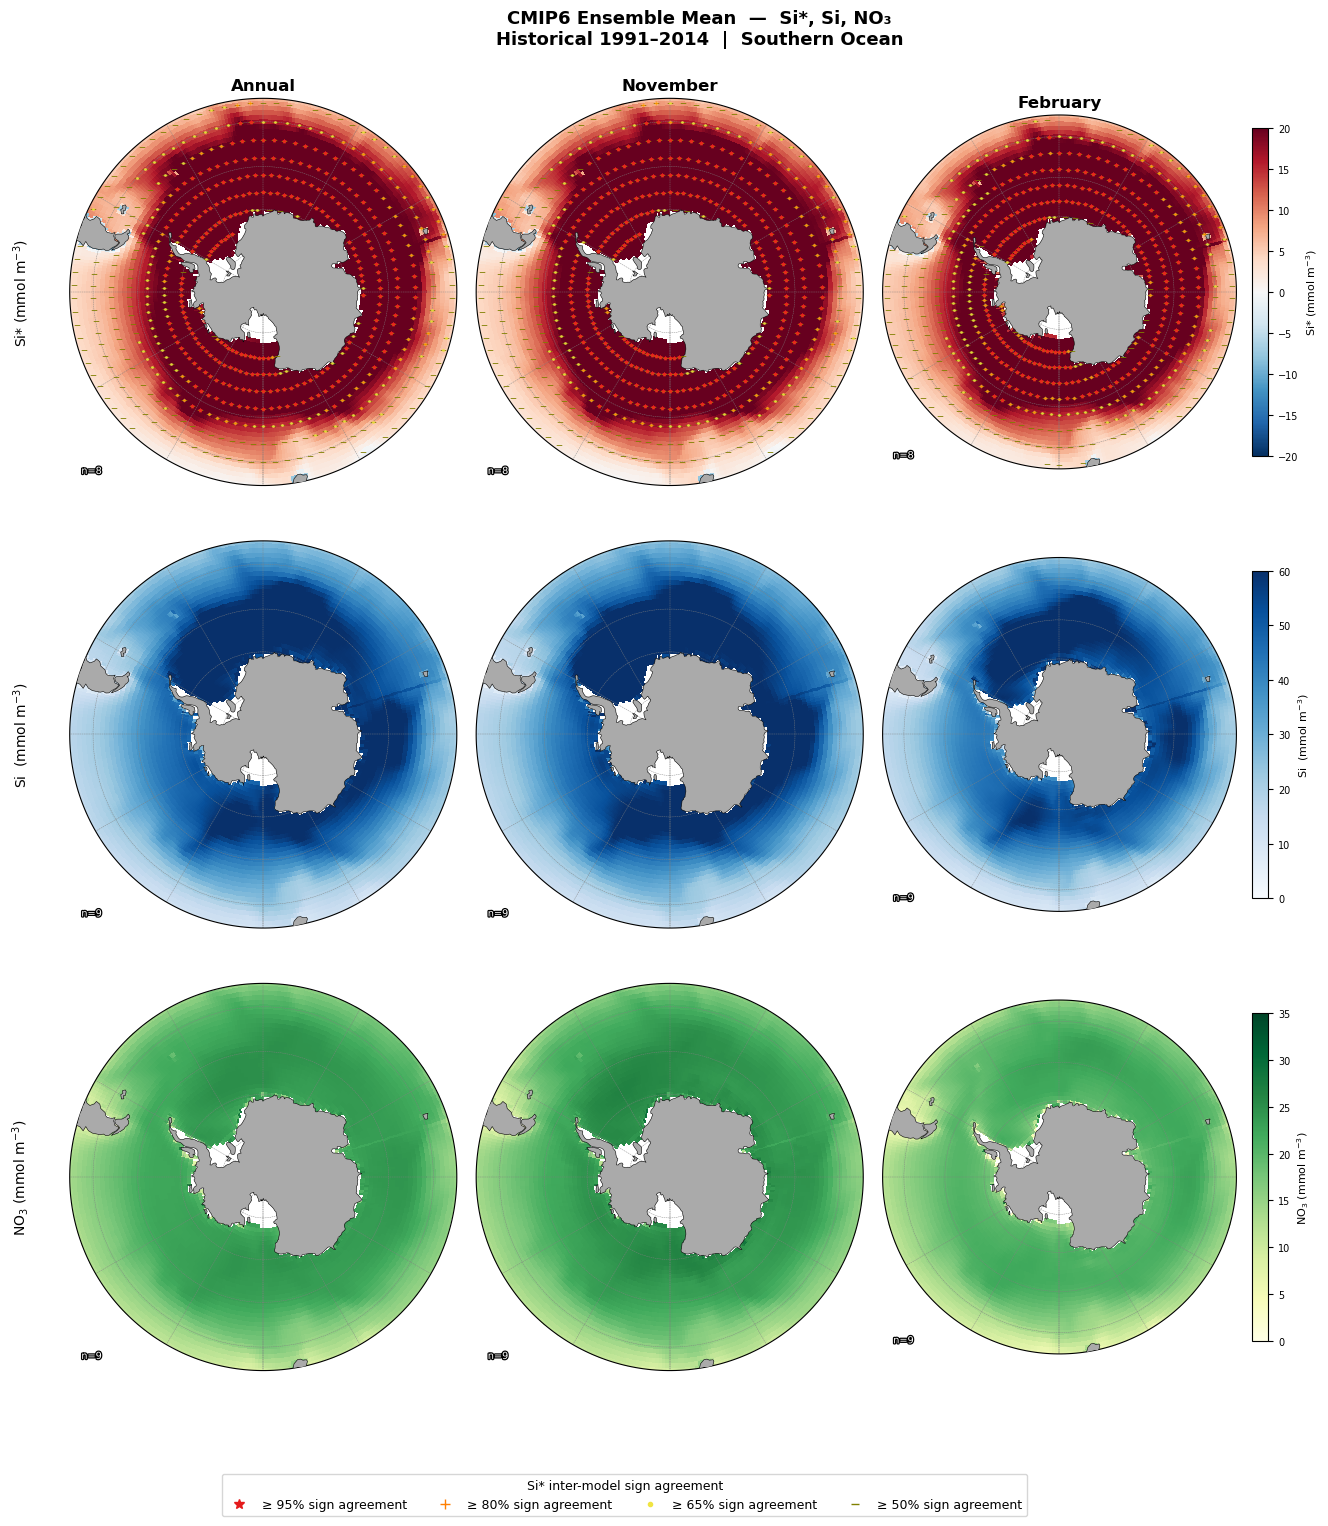

In [21]:
"""
ensemble_polar_maps.py
─────────────────────────────────────────────────────────────────────────────
3-row × 3-col figure: (Si*, Si, NO3) × (Annual, November, February)
Stippling (Si* only): * ≥90%  + ≥80%  . ≥70%  sign agreement
─────────────────────────────────────────────────────────────────────────────
"""

import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ─── CONFIG ──────────────────────────────────────────────────────────────────
SAVE_DIR   = "/glade/work/diegovar/climatologies_spatial1"
START_YEAR = "1991"
END_YEAR   = "2014"

MODELS = [
    "CESM2", "CESM2-WACCM",
    "GFDL-CM4", "GFDL-ESM4",
    "IPSL-CM6A-LR",
    "GISS-E2-1-G",
    "MIROC-ES2L",
    "NorCPM1", "NorESM2-LM", "NorESM2-MM",
    "MPI-ESM-1-2-HAM", "MPI-ESM1-2-HR",
    "UKESM1-0-LL",
    "CNRM-ESM2-1",
    "ACCESS-ESM1-5",
    "CanESM5", "CanESM5-CanOE",
    "CMCC-ESM2",
]

SKIP_COMBOS = {
}

VARIABLES  = ["sistar", "si", "no3"]
VAR_LABELS = {
    "sistar": r"Si* (mmol m$^{-3}$)",
    "si"    : r"Si  (mmol m$^{-3}$)",
    "no3"   : r"NO$_3$ (mmol m$^{-3}$)",
}
CMAPS = {"sistar": "RdBu_r", "si": "Blues",  "no3": "YlGn"}
VLIMS = {"sistar": (-20, 20), "si": (0, 60), "no3": (0, 35)}

TIME_PERIODS = {
    "Annual"  : None,
    "November": 11,
    "February": 2,
}

# (threshold, marker, size, color)
STIPPLE_LEVELS = [
    (0.50, "_", 14,  "#808000"),   # yellow  — ≥ 70%
    (0.65, ".", 10,  "#f0e442"),   # yellow  — ≥ 70%
    (0.80, "+", 10,  "#ff7f00"),   # orange  — ≥ 85%
    (0.95, "*", 10,  "#e41a1c"),   # red     — ≥ 95%
]
STIPPLE_DENSITY  = 4

OUTPUT_FIG = "ensemble_polar_nutrients.png"
# ─────────────────────────────────────────────────────────────────────────────


def get_path(model, var):
    return os.path.join(SAVE_DIR, f"{model}_{var}_{START_YEAR}{END_YEAR}_spatial.nc")


def load_period(model, var, month):
    if (model, var) in SKIP_COMBOS:
        return None, None, None
    path = get_path(model, var)
    if not os.path.exists(path):
        print(f"  [missing] {path}")
        return None, None, None

    ds = xr.open_dataset(path)
    da = ds[var]                           # (month, lat, lon)

    # ── Clip to 90S–50S ───────────────────────────────────────────────────
    da = da.sel(lat=slice(-90, -45))

    # ── Normalize longitude to 0–360 and sort ────────────────────────────
    lon      = da["lon"].values % 360
    sort_idx = np.argsort(lon)
    da       = da.isel(lon=sort_idx)
    da       = da.assign_coords(lon=lon[sort_idx])

    field = da.mean("month").values if month is None else da.sel(month=month).values
    return field, da["lat"].values, da["lon"].values


def build_ensemble(var, month):
    fields  = []
    lat_ref = lon_ref = None

    for model in MODELS:
        field, _lat, _lon = load_period(model, var, month)
        if field is None:
            continue

        if lat_ref is None:
            lat_ref, lon_ref = _lat, _lon
            fields.append(field)
            continue

        # ── Align longitude ───────────────────────────────────────────
        if _lon.shape != lon_ref.shape or not np.allclose(_lon, lon_ref, atol=0.5):
            print(f"  [align lon] {model}")
            # field shape: (lat, lon) — interpolate each latitude row
            field = np.array([
                np.interp(lon_ref, _lon, field[i], period=360)
                for i in range(field.shape[0])   # iterate over lat rows ✓
            ])
            # field is now (len(_lat), len(lon_ref))

        # ── Align latitude ────────────────────────────────────────────
        if _lat.shape != lat_ref.shape or not np.allclose(_lat, lat_ref, atol=0.5):
            print(f"  [align lat] {model}")
            # field shape: (lat, lon) — interpolate each longitude column
            field = np.array([
                np.interp(lat_ref, _lat, field[:, j])  # iterate over lon columns ✓
                for j in range(field.shape[1])
            ]).T   # transpose back to (lat, lon)

        fields.append(field)

    if not fields:
        raise RuntimeError(f"No data for var={var}, month={month}")

    stack    = np.stack(fields, axis=0)
    ens_mean = np.nanmean(stack, axis=0)
    agree    = np.nanmean(
        np.sign(stack) == np.sign(ens_mean)[np.newaxis], axis=0
    )
    return ens_mean, agree, lat_ref, lon_ref, len(fields)


# ── map helpers ───────────────────────────────────────────────────────────────

def circular_boundary(ax):
    theta = np.linspace(0, 2 * np.pi, 300)
    verts = np.column_stack([np.sin(theta), np.cos(theta)])
    ax.set_boundary(mpath.Path(verts * 0.5 + 0.5), transform=ax.transAxes)


def setup_ax(ax):
    ax.set_extent([-180, 180, -90, -45], crs=ccrs.PlateCarree())
    circular_boundary(ax)
    ax.add_feature(cfeature.LAND,      facecolor="#aaaaaa", zorder=4)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4,        zorder=5)
    gl = ax.gridlines(crs=ccrs.PlateCarree(),
                      linewidth=0.3, color="grey", linestyle="--", zorder=3)
    gl.xlocator = plt.FixedLocator(range(-180, 181, 30))
    gl.ylocator = plt.FixedLocator([-80, -70, -60, -50])


def add_stippling(ax, lon2d, lat2d, agree):
    d  = STIPPLE_DENSITY
    ag = agree[::d, ::d]
    lo = lon2d[::d, ::d]
    la = lat2d[::d, ::d]
    for thresh, marker, size, color in STIPPLE_LEVELS:
        mask = ag >= thresh
        if not mask.any():
            continue
        ax.scatter(lo[mask], la[mask],
                   marker=marker, s=size, c=color, alpha=0.85,
                   linewidths=0.4, transform=ccrs.PlateCarree(), zorder=6)


# ── main figure ───────────────────────────────────────────────────────────────

def make_figure():
    period_names   = list(TIME_PERIODS.keys())
    n_rows, n_cols = len(VARIABLES), len(period_names)
    proj           = ccrs.SouthPolarStereo(central_longitude=0)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5.0 * n_cols, 5.2 * n_rows),
        subplot_kw={"projection": proj},
    )
    fig.subplots_adjust(hspace=0.08, wspace=0.05,
                        top=0.93, bottom=0.10, left=0.08, right=0.88)

    for row, var in enumerate(VARIABLES):
        for col, pname in enumerate(period_names):
            ax    = axes[row, col]
            month = TIME_PERIODS[pname]

            print(f"\n── {var}  |  {pname} ──")
            try:
                ens_mean, agree, lat, lon, n_mod = build_ensemble(var, month)
            except RuntimeError:
                ax.set_title("[NO DATA]", fontsize=8)
                ax.axis("off")
                continue

            lon2d, lat2d = np.meshgrid(lon, lat)

            setup_ax(ax)

            cf = ax.pcolormesh(
                lon2d, lat2d, ens_mean,
                vmin=VLIMS[var][0], vmax=VLIMS[var][1],
                cmap=CMAPS[var],
                transform=ccrs.PlateCarree(),
                shading="auto", zorder=1,
            )

            if var == "sistar":
                add_stippling(ax, lon2d, lat2d, agree)

            if row == 0:
                ax.set_title(pname, fontsize=12, fontweight="bold", pad=6)
            if col == 0:
                ax.text(-0.10, 0.5, VAR_LABELS[var],
                        va="center", ha="right", rotation=90,
                        fontsize=10, transform=ax.transAxes)

            ax.text(0.03, 0.03, f"n={n_mod}", fontsize=7, color="white",
                    transform=ax.transAxes, zorder=7,
                    path_effects=[pe.withStroke(linewidth=1.8, foreground="k")])

            if col == n_cols - 1:
                cbar = fig.colorbar(cf, ax=ax,
                                    orientation="vertical",
                                    fraction=0.046, pad=0.04, shrink=0.80)
                cbar.set_label(VAR_LABELS[var], fontsize=8)
                cbar.ax.tick_params(labelsize=7)

    fig.legend(
        handles=[
            Line2D([0],[0], marker="*", color="#e41a1c", linestyle="None",
                   markersize=7, label="≥ 95% sign agreement"),
            Line2D([0],[0], marker="+", color="#ff7f00", linestyle="None",
                   markersize=7, label="≥ 80% sign agreement"),
            Line2D([0],[0], marker=".", color="#f0e442", linestyle="None",
                   markersize=6, label="≥ 65% sign agreement"),
            Line2D([0],[0], marker="_", color="#808000", linestyle="None",
                   markersize=6, label="≥ 50% sign agreement"),
        ],
        loc="lower center", ncol=4, fontsize=9, frameon=True,
        bbox_to_anchor=(0.45, 0.01),
        title="Si* inter-model sign agreement", title_fontsize=9,
    )

    fig.suptitle(
        f"CMIP6 Ensemble Mean  —  Si*, Si, NO₃\n"
        f"Historical {START_YEAR}–{END_YEAR}  |  Southern Ocean",
        fontsize=13, fontweight="bold",
    )

    plt.savefig(OUTPUT_FIG, dpi=300, bbox_inches="tight")
    print(f"\nSaved → {OUTPUT_FIG}")
    plt.show()


if __name__ == "__main__":
    make_figure()


── sistar  |  Annual ──
  [missing] /glade/work/diegovar/climatologies_spatial1/GFDL-CM4_sistar_19912014_spatial.nc
  [align lat] IPSL-CM6A-LR
  [missing] /glade/work/diegovar/climatologies_spatial1/GISS-E2-1-G_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/MIROC-ES2L_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/NorCPM1_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/MPI-ESM-1-2-HAM_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/UKESM1-0-LL_sistar_19912014_spatial.nc
  [align lat] CNRM-ESM2-1
  [missing] /glade/work/diegovar/climatologies_spatial1/ACCESS-ESM1-5_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/CanESM5_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/CanESM5-CanOE_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/CMCC-ESM2_sista

/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,



── sistar  |  November ──
  [missing] /glade/work/diegovar/climatologies_spatial1/GFDL-CM4_sistar_19912014_spatial.nc
  [align lat] IPSL-CM6A-LR
  [missing] /glade/work/diegovar/climatologies_spatial1/GISS-E2-1-G_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/MIROC-ES2L_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/NorCPM1_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/MPI-ESM-1-2-HAM_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/UKESM1-0-LL_sistar_19912014_spatial.nc
  [align lat] CNRM-ESM2-1
  [missing] /glade/work/diegovar/climatologies_spatial1/ACCESS-ESM1-5_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/CanESM5_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/CanESM5-CanOE_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/CMCC-ESM2_sis

/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,



── sistar  |  February ──
  [missing] /glade/work/diegovar/climatologies_spatial1/GFDL-CM4_sistar_19912014_spatial.nc
  [align lat] IPSL-CM6A-LR
  [missing] /glade/work/diegovar/climatologies_spatial1/GISS-E2-1-G_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/MIROC-ES2L_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/NorCPM1_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/MPI-ESM-1-2-HAM_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/UKESM1-0-LL_sistar_19912014_spatial.nc
  [align lat] CNRM-ESM2-1
  [missing] /glade/work/diegovar/climatologies_spatial1/ACCESS-ESM1-5_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/CanESM5_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/CanESM5-CanOE_sistar_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/CMCC-ESM2_sis

...


── no3  |  November ──
  [missing] /glade/work/diegovar/climatologies_spatial1/GFDL-CM4_no3_19912014_spatial.nc
  [align lat] IPSL-CM6A-LR
  [missing] /glade/work/diegovar/climatologies_spatial1/GISS-E2-1-G_no3_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/MIROC-ES2L_no3_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/NorCPM1_no3_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/MPI-ESM-1-2-HAM_no3_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/UKESM1-0-LL_no3_19912014_spatial.nc
  [align lat] CNRM-ESM2-1
  [missing] /glade/work/diegovar/climatologies_spatial1/ACCESS-ESM1-5_no3_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/CanESM5-CanOE_no3_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/CMCC-ESM2_no3_19912014_spatial.nc


/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,



── no3  |  February ──
  [missing] /glade/work/diegovar/climatologies_spatial1/GFDL-CM4_no3_19912014_spatial.nc
  [align lat] IPSL-CM6A-LR
  [missing] /glade/work/diegovar/climatologies_spatial1/GISS-E2-1-G_no3_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/MIROC-ES2L_no3_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/NorCPM1_no3_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/MPI-ESM-1-2-HAM_no3_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/UKESM1-0-LL_no3_19912014_spatial.nc
  [align lat] CNRM-ESM2-1
  [missing] /glade/work/diegovar/climatologies_spatial1/ACCESS-ESM1-5_no3_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/CanESM5-CanOE_no3_19912014_spatial.nc
  [missing] /glade/work/diegovar/climatologies_spatial1/CMCC-ESM2_no3_19912014_spatial.nc


/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,



Saved → ensemble_polar_nutrients_iqr.png


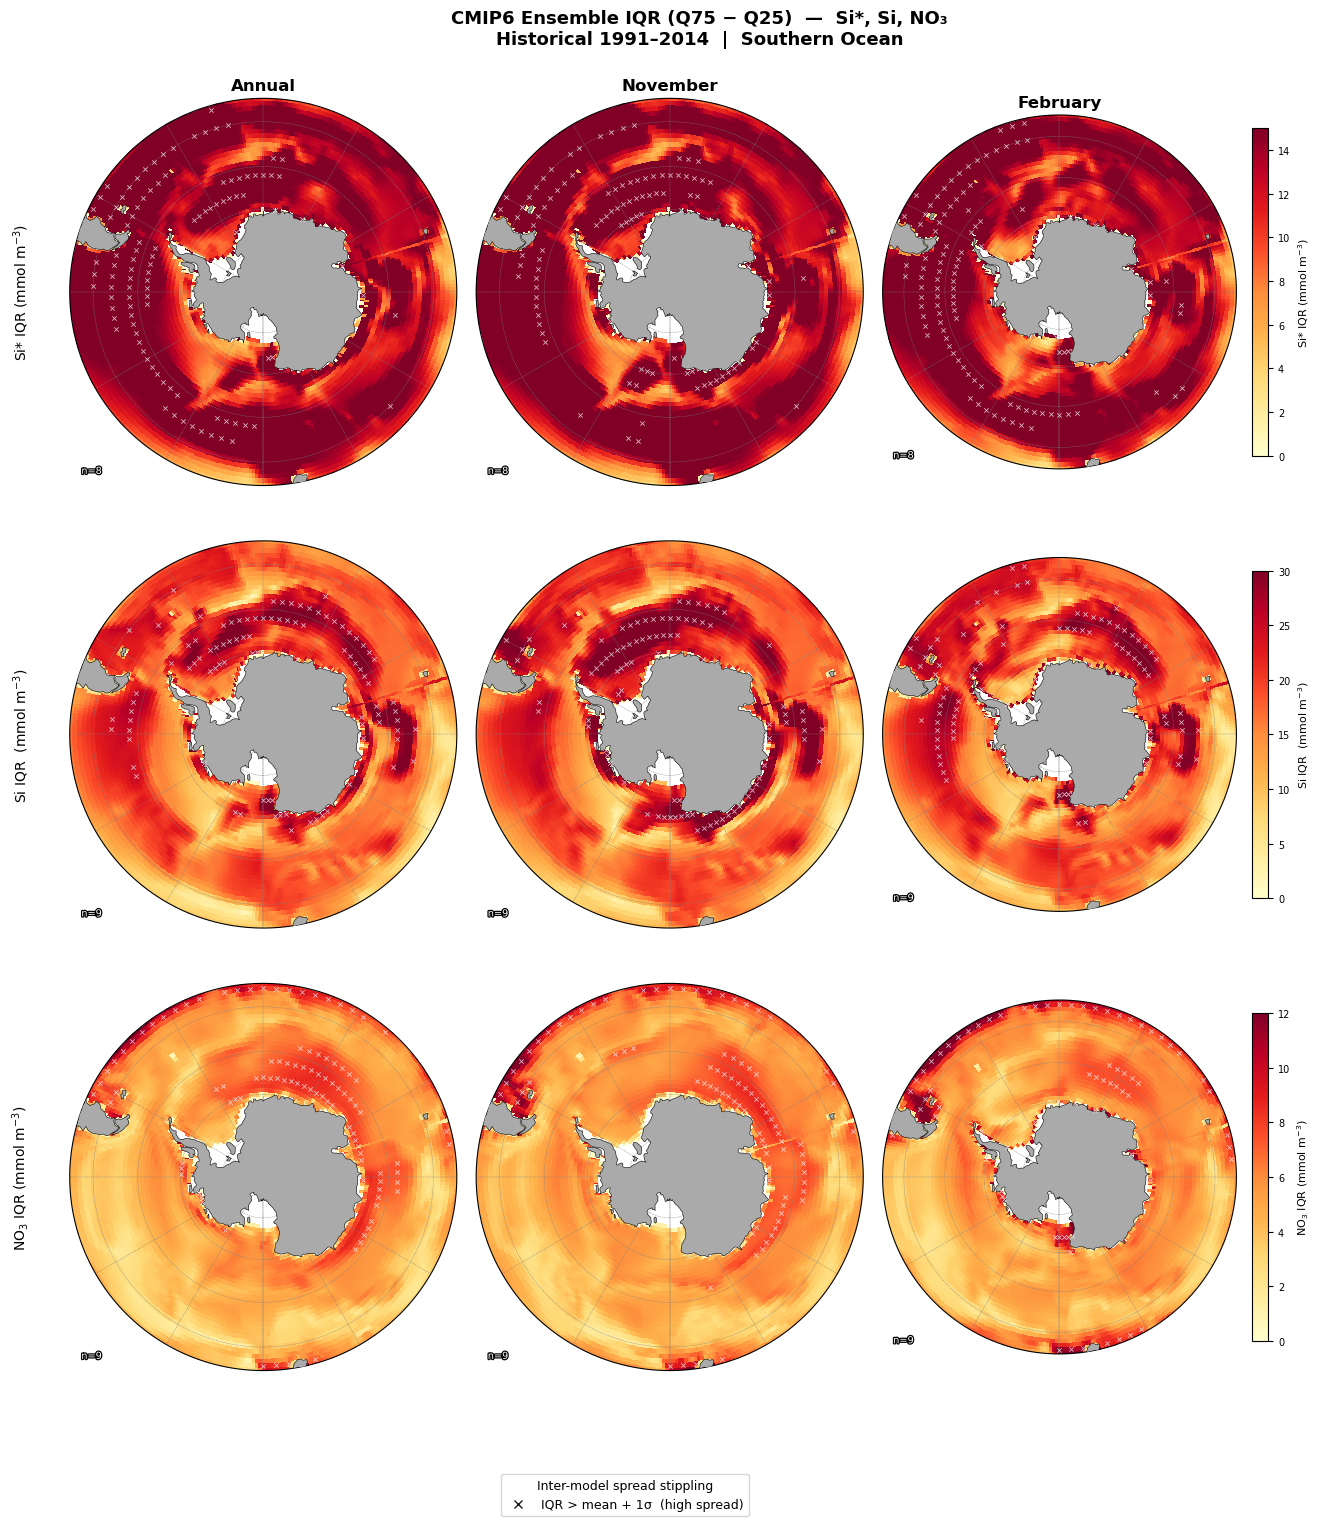

In [14]:
"""
ensemble_polar_maps_iqr.py
─────────────────────────────────────────────────────────────────────────────
3-row × 3-col figure: (Si*, Si, NO3) × (Annual, November, February)
Shows the INTERQUARTILE RANGE (IQR = Q75 - Q25) across the CMIP6 ensemble
at each grid cell, as a measure of inter-model spread / uncertainty.

Stippling (all variables): marks where IQR > 1 std dev of the IQR field,
i.e. regions of exceptionally high model disagreement.

Mirrors the layout, config, and helpers of ensemble_polar_maps.py exactly.
─────────────────────────────────────────────────────────────────────────────
"""

import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ─── CONFIG — identical to ensemble_polar_maps.py ────────────────────────────
SAVE_DIR   = "/glade/work/diegovar/climatologies_spatial1"
START_YEAR = "1991"
END_YEAR   = "2014"

MODELS = [
    "CESM2", "CESM2-WACCM",
    "GFDL-CM4", "GFDL-ESM4",
    "IPSL-CM6A-LR",
    "GISS-E2-1-G",
    "MIROC-ES2L",
    "NorCPM1", "NorESM2-LM", "NorESM2-MM",
    "MPI-ESM-1-2-HAM", "MPI-ESM1-2-HR",
    "UKESM1-0-LL",
    "CNRM-ESM2-1",
    "ACCESS-ESM1-5",
    "CanESM5", "CanESM5-CanOE",
    "CMCC-ESM2",
]

SKIP_COMBOS = {}

VARIABLES  = ["sistar", "si", "no3"]
VAR_LABELS = {
    "sistar": r"Si* IQR (mmol m$^{-3}$)",
    "si"    : r"Si IQR  (mmol m$^{-3}$)",
    "no3"   : r"NO$_3$ IQR (mmol m$^{-3}$)",
}

# IQR is always non-negative → sequential colormaps
CMAPS = {
    "sistar": "YlOrRd",   # yellow→red: spreads in a signed variable
    "si"    : "YlOrRd",
    "no3"   : "YlOrRd",
}

# Upper bounds tuned to typical inter-model IQR ranges in the SO
VLIMS = {
    "sistar": (0, 15),
    "si"    : (0, 30),
    "no3"   : (0, 12),
}

TIME_PERIODS = {
    "Annual"  : None,
    "November": 11,
    "February": 2,
}

# Stippling: cells where IQR > (mean_IQR + 1*std_IQR), i.e. hotspots of spread
STIPPLE_DENSITY = 4   # plot every Nth grid point

OUTPUT_FIG = "ensemble_polar_nutrients_iqr.png"
# ─────────────────────────────────────────────────────────────────────────────


def get_path(model, var):
    return os.path.join(SAVE_DIR, f"{model}_{var}_{START_YEAR}{END_YEAR}_spatial.nc")


def load_period(model, var, month):
    """Load and pre-process one model field. Returns (field, lat, lon) or Nones."""
    if (model, var) in SKIP_COMBOS:
        return None, None, None
    path = get_path(model, var)
    if not os.path.exists(path):
        print(f"  [missing] {path}")
        return None, None, None

    ds = xr.open_dataset(path)
    da = ds[var]                           # (month, lat, lon)

    # Clip to Southern Ocean domain
    da = da.sel(lat=slice(-90, -45))

    # Normalize longitude to 0–360 and sort
    lon      = da["lon"].values % 360
    sort_idx = np.argsort(lon)
    da       = da.isel(lon=sort_idx)
    da       = da.assign_coords(lon=lon[sort_idx])

    field = da.mean("month").values if month is None else da.sel(month=month).values
    return field, da["lat"].values, da["lon"].values


def build_ensemble_iqr(var, month):
    """
    Collect all model fields onto a common grid, then compute:
      - Q25, Q75, IQR  at every grid cell
      - A boolean 'high_spread' mask: IQR > mean(IQR) + 1*std(IQR)

    Returns: iqr, high_spread, lat_ref, lon_ref, n_models
    """
    fields  = []
    lat_ref = lon_ref = None

    for model in MODELS:
        field, _lat, _lon = load_period(model, var, month)
        if field is None:
            continue

        if lat_ref is None:
            lat_ref, lon_ref = _lat, _lon
            fields.append(field)
            continue

        # ── Align longitude (interpolate each lat row) ────────────────
        if _lon.shape != lon_ref.shape or not np.allclose(_lon, lon_ref, atol=0.5):
            print(f"  [align lon] {model}")
            field = np.array([
                np.interp(lon_ref, _lon, field[i], period=360)
                for i in range(field.shape[0])
            ])

        # ── Align latitude (interpolate each lon column) ──────────────
        if _lat.shape != lat_ref.shape or not np.allclose(_lat, lat_ref, atol=0.5):
            print(f"  [align lat] {model}")
            field = np.array([
                np.interp(lat_ref, _lat, field[:, j])
                for j in range(field.shape[1])
            ]).T   # shape back to (lat, lon)

        fields.append(field)

    if not fields:
        raise RuntimeError(f"No data for var={var}, month={month}")

    # Stack → (n_models, lat, lon)
    stack = np.stack(fields, axis=0)

    q25 = np.nanpercentile(stack, 25, axis=0)
    q75 = np.nanpercentile(stack, 75, axis=0)
    iqr = q75 - q25                        # always ≥ 0

    # Hotspot mask: IQR one std-dev above the spatial mean IQR
    iqr_mean = np.nanmean(iqr)
    iqr_std  = np.nanstd(iqr)
    high_spread = iqr > (iqr_mean + iqr_std)

    return iqr, high_spread, lat_ref, lon_ref, len(fields)


# ── Map helpers (identical to ensemble_polar_maps.py) ────────────────────────

def circular_boundary(ax):
    theta = np.linspace(0, 2 * np.pi, 300)
    verts = np.column_stack([np.sin(theta), np.cos(theta)])
    ax.set_boundary(mpath.Path(verts * 0.5 + 0.5), transform=ax.transAxes)


def setup_ax(ax):
    ax.set_extent([-180, 180, -90, -45], crs=ccrs.PlateCarree())
    circular_boundary(ax)
    ax.add_feature(cfeature.LAND,      facecolor="#aaaaaa", zorder=4)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4,        zorder=5)
    gl = ax.gridlines(crs=ccrs.PlateCarree(),
                      linewidth=0.3, color="grey", linestyle="--", zorder=3)
    gl.xlocator = plt.FixedLocator(range(-180, 181, 30))
    gl.ylocator = plt.FixedLocator([-80, -70, -60, -50])


def add_highspread_stippling(ax, lon2d, lat2d, high_spread):
    """Hatch cells where IQR is anomalously large (> mean + 1σ)."""
    d  = STIPPLE_DENSITY
    hs = high_spread[::d, ::d]
    lo = lon2d[::d, ::d]
    la = lat2d[::d, ::d]
    if hs.any():
        ax.scatter(lo[hs], la[hs],
                   marker="x", s=10, c="#FFFFFF", alpha=0.70,
                   linewidths=0.6, transform=ccrs.PlateCarree(), zorder=6)


# ── Main figure ───────────────────────────────────────────────────────────────

def make_figure():
    period_names   = list(TIME_PERIODS.keys())
    n_rows, n_cols = len(VARIABLES), len(period_names)
    proj           = ccrs.SouthPolarStereo(central_longitude=0)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5.0 * n_cols, 5.2 * n_rows),
        subplot_kw={"projection": proj},
    )
    fig.subplots_adjust(hspace=0.08, wspace=0.05,
                        top=0.93, bottom=0.10, left=0.08, right=0.88)

    for row, var in enumerate(VARIABLES):
        for col, pname in enumerate(period_names):
            ax    = axes[row, col]
            month = TIME_PERIODS[pname]

            print(f"\n── {var}  |  {pname} ──")
            try:
                iqr, high_spread, lat, lon, n_mod = build_ensemble_iqr(var, month)
            except RuntimeError:
                ax.set_title("[NO DATA]", fontsize=8)
                ax.axis("off")
                continue

            lon2d, lat2d = np.meshgrid(lon, lat)

            setup_ax(ax)

            cf = ax.pcolormesh(
                lon2d, lat2d, iqr,
                vmin=VLIMS[var][0], vmax=VLIMS[var][1],
                cmap=CMAPS[var],
                transform=ccrs.PlateCarree(),
                shading="auto", zorder=1,
            )

            # Stipple high-spread regions
            add_highspread_stippling(ax, lon2d, lat2d, high_spread)

            # Column headers (season labels)
            if row == 0:
                ax.set_title(pname, fontsize=12, fontweight="bold", pad=6)

            # Row labels (variable names)
            if col == 0:
                ax.text(-0.10, 0.5, VAR_LABELS[var],
                        va="center", ha="right", rotation=90,
                        fontsize=10, transform=ax.transAxes)

            # Model count badge
            ax.text(0.03, 0.03, f"n={n_mod}", fontsize=7, color="white",
                    transform=ax.transAxes, zorder=7,
                    path_effects=[pe.withStroke(linewidth=1.8, foreground="k")])

            # Colourbar on the rightmost column
            if col == n_cols - 1:
                cbar = fig.colorbar(cf, ax=ax,
                                    orientation="vertical",
                                    fraction=0.046, pad=0.04, shrink=0.80)
                cbar.set_label(VAR_LABELS[var], fontsize=8)
                cbar.ax.tick_params(labelsize=7)

    # ── Legend ────────────────────────────────────────────────────────────
    fig.legend(
        handles=[
            Line2D([0], [0], marker="x", color="#1a1a1a", linestyle="None",
                   markersize=6, label="IQR > mean + 1σ  (high spread)"),
        ],
        loc="lower center", ncol=1, fontsize=9, frameon=True,
        bbox_to_anchor=(0.45, 0.01),
        title="Inter-model spread stippling", title_fontsize=9,
    )

    # ── Super-title ───────────────────────────────────────────────────────
    fig.suptitle(
        f"CMIP6 Ensemble IQR (Q75 − Q25)  —  Si*, Si, NO₃\n"
        f"Historical {START_YEAR}–{END_YEAR}  |  Southern Ocean",
        fontsize=13, fontweight="bold",
    )

    plt.savefig(OUTPUT_FIG, dpi=300, bbox_inches="tight")
    print(f"\nSaved → {OUTPUT_FIG}")
    plt.show()


if __name__ == "__main__":
    make_figure()